
[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Epoch 20/50 - Loss: 0.385
Epoch 40/50 - Loss: 0.024


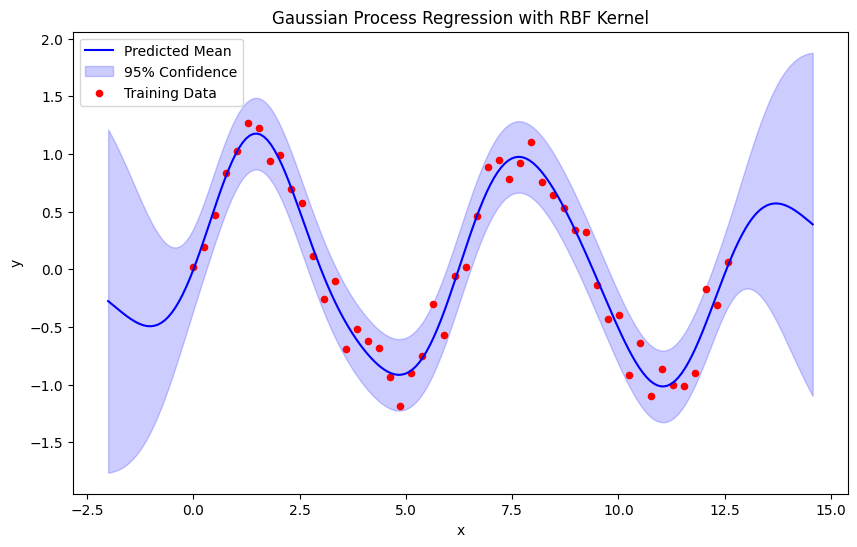

In [12]:
%pip install gpytorch

import torch
import gpytorch
import matplotlib.pyplot as plt

# Generate synthetic training data
def generate_data(n=100):
    x = torch.linspace(0, 4 * torch.pi, n)
    y = torch.sin(x) + 0.2 * torch.randn(n)  # Sine wave with noise
    return x, y

train_x, train_y = generate_data(n=50)

# Define GP model (same as before)
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, lengthscale=1.0, alpha=1.0):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )
        # Initialize hyperparameters
        self.covar_module.base_kernel.lengthscale = lengthscale
        self.covar_module.outputscale = alpha**2
        
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Initialize model and likelihood
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood, lengthscale=0.2, alpha=1.0)

# Training loop
def train_model(model, train_x, train_y, n_epochs=100):
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} - Loss: {loss.item():.3f}")

train_model(model, train_x, train_y, n_epochs=50)

# Inference on test points
model.eval()
likelihood.eval()

# Generate test points (including extrapolation)
test_x = torch.linspace(-2, 4 * torch.pi + 2, 200)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))
    predictive_mean = observed_pred.mean
    predictive_std = observed_pred.stddev

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(test_x.numpy(), predictive_mean.numpy(), 'b', label='Predicted Mean')
plt.fill_between(
    test_x.numpy(),
    (predictive_mean - 2 * predictive_std).numpy(),
    (predictive_mean + 2 * predictive_std).numpy(),
    alpha=0.2,
    color='b',
    label='95% Confidence'
)
plt.scatter(train_x.numpy(), train_y.numpy(), c='r', label='Training Data', s=20)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gaussian Process Regression with RBF Kernel")
plt.legend()
plt.show()

Epoch 20/50 - Loss: 0.627
Epoch 40/50 - Loss: 0.261


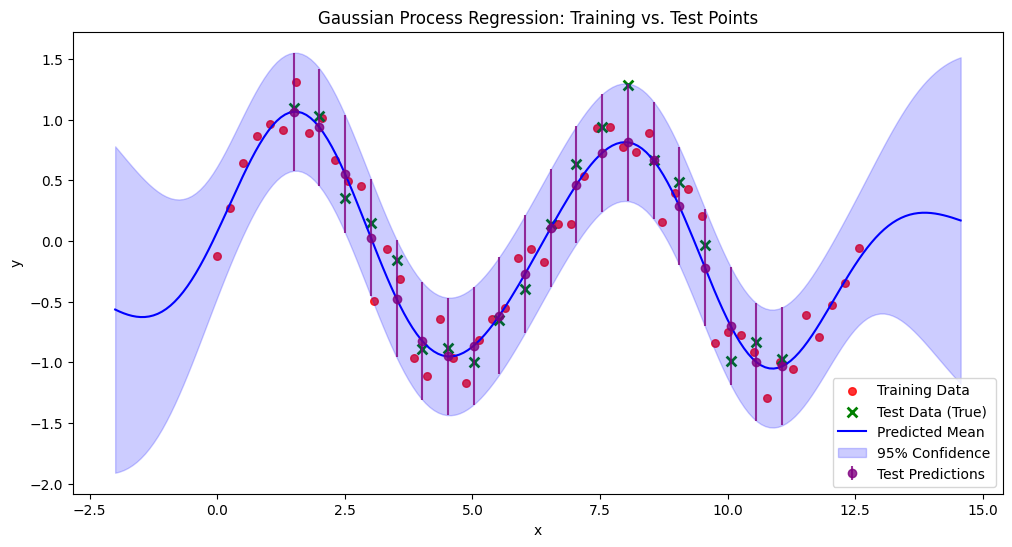

In [11]:
import torch
import gpytorch
import matplotlib.pyplot as plt

# Generate synthetic data with training and held-out test points
def generate_data(n_train=50, n_test=20):
    # Training data (observed)
    train_x = torch.linspace(0, 4 * torch.pi, n_train)
    train_y = torch.sin(train_x) + 0.2 * torch.randn(n_train)  # Noisy sine wave
    
    # Test data (held-out, with true values)
    test_x = torch.linspace(1.5, 4 * torch.pi - 1.5, n_test)  # Avoid overlapping with training extremes
    test_y = torch.sin(test_x) + 0.2 * torch.randn(n_test)  # Noisy sine wave
    
    return train_x, train_y, test_x, test_y

train_x, train_y, test_x, test_y = generate_data()

# Define GP model (same as before)
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, lengthscale=0.01, alpha=2.0):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )
        # Initialize hyperparameters
        self.covar_module.base_kernel.lengthscale = lengthscale
        self.covar_module.outputscale = alpha**2
        
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Initialize model and likelihood
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood, lengthscale=.07, alpha=1.0)

# Training loop
def train_model(model, train_x, train_y, n_epochs=100):
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} - Loss: {loss.item():.3f}")

train_model(model, train_x, train_y, n_epochs=50)

# Inference on held-out test points
model.eval()
likelihood.eval()

# Generate dense grid for prediction visualization
plot_x = torch.linspace(-2, 4 * torch.pi + 2, 200)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Predictions for visualization grid
    plot_pred = likelihood(model(plot_x))
    plot_mean = plot_pred.mean
    plot_std = plot_pred.stddev
    
    # Predictions for held-out test points
    test_pred = likelihood(model(test_x))
    test_mean = test_pred.mean
    test_std = test_pred.stddev

# Plot results
plt.figure(figsize=(12, 6))
# Training data
plt.scatter(train_x.numpy(), train_y.numpy(), c='r', label='Training Data', s=30, alpha=0.8)
# Held-out test data (true values)
plt.scatter(test_x.numpy(), test_y.numpy(), c='green', marker='x', label='Test Data (True)', s=50, linewidth=2)
# Predictions for test points (mean ± 2σ)
plt.errorbar(test_x.numpy(), test_mean.numpy(), yerr=2*test_std.numpy(), 
             fmt='o', color='purple', label='Test Predictions', alpha=0.8)
# Predictive mean and uncertainty for visualization grid
plt.plot(plot_x.numpy(), plot_mean.numpy(), 'b', label='Predicted Mean')
plt.fill_between(
    plot_x.numpy(),
    (plot_mean - 2 * plot_std).numpy(),
    (plot_mean + 2 * plot_std).numpy(),
    alpha=0.2,
    color='b',
    label='95% Confidence'
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gaussian Process Regression: Training vs. Test Points")
plt.legend()
plt.show()

Epoch 20/50 - Loss: 0.859
Epoch 40/50 - Loss: 0.725


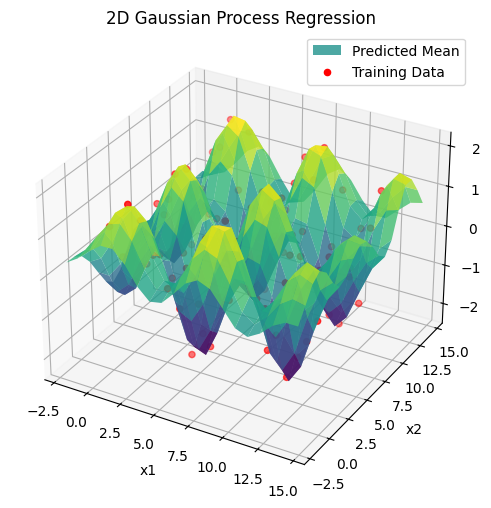

In [2]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate 2D synthetic data (sinusoidal surface with noise)
def generate_2d_data(n=100):
    x1 = torch.linspace(0, 4 * torch.pi, int(np.sqrt(n)))
    x2 = torch.linspace(0, 4 * torch.pi, int(np.sqrt(n)))
    x1_grid, x2_grid = torch.meshgrid(x1, x2, indexing='ij')
    x = torch.stack([x1_grid.flatten(), x2_grid.flatten()], dim=1)
    y = torch.sin(x1_grid).flatten() + torch.cos(x2_grid).flatten() + 0.2 * torch.randn(n)
    return x, y

train_x, train_y = generate_2d_data(n=100)  # 10x10 grid

# Define GP model for 2D input
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, lengthscale=1.0, alpha=1.0):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=2)  # ARD for 2D input
        )
        # Initialize hyperparameters
        self.covar_module.base_kernel.lengthscale = torch.tensor([lengthscale, lengthscale])
        self.covar_module.outputscale = alpha**2
        
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Initialize model and likelihood
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood, lengthscale=1.0, alpha=1.0)

# Training loop
def train_model(model, train_x, train_y, n_epochs=100):
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} - Loss: {loss.item():.3f}")

train_model(model, train_x, train_y, n_epochs=50)

# Generate test grid for prediction
test_res = 20
test_x1 = torch.linspace(-2, 4 * torch.pi + 2, test_res)
test_x2 = torch.linspace(-2, 4 * torch.pi + 2, test_res)
test_x1_grid, test_x2_grid = torch.meshgrid(test_x1, test_x2, indexing='ij')
test_x = torch.stack([test_x1_grid.flatten(), test_x2_grid.flatten()], dim=1)

# Inference
model.eval()
likelihood.eval()
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))
    predictive_mean = observed_pred.mean.reshape(test_res, test_res)
    predictive_std = observed_pred.stddev.reshape(test_res, test_res)

# Plot results
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot predictive mean surface
surf = ax.plot_surface(
    test_x1_grid.numpy(), test_x2_grid.numpy(), predictive_mean.numpy(),
    cmap='viridis', alpha=0.8, label='Predicted Mean'
)

# Plot training data
ax.scatter(
    train_x[:, 0].numpy(), train_x[:, 1].numpy(), train_y.numpy(),
    c='r', s=20, label='Training Data'
)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('2D Gaussian Process Regression')
plt.legend()
plt.show()

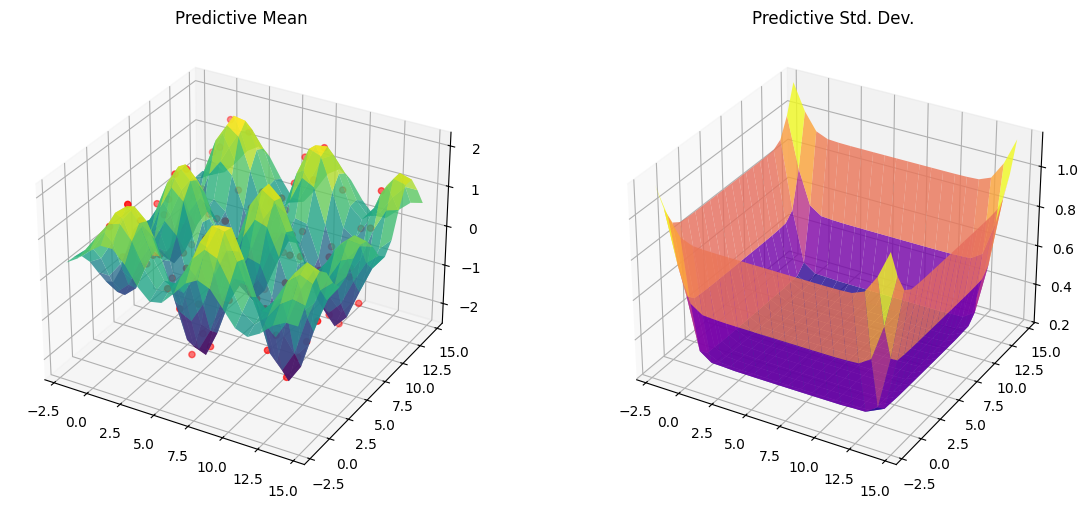

In [3]:
# Add uncertainty surface
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(121, projection='3d')
ax.set_title('Predictive Mean')
ax.plot_surface(test_x1_grid.numpy(), test_x2_grid.numpy(), predictive_mean.numpy(), cmap='viridis', alpha=0.8)
ax.scatter(train_x[:, 0], train_x[:, 1], train_y, c='r', s=20)

ax2 = fig.add_subplot(122, projection='3d')
ax2.set_title('Predictive Std. Dev.')
ax2.plot_surface(test_x1_grid.numpy(), test_x2_grid.numpy(), predictive_std.numpy(), cmap='plasma', alpha=0.8)
plt.show()

Epoch 20/50 - Loss: 0.247
Epoch 40/50 - Loss: -0.042


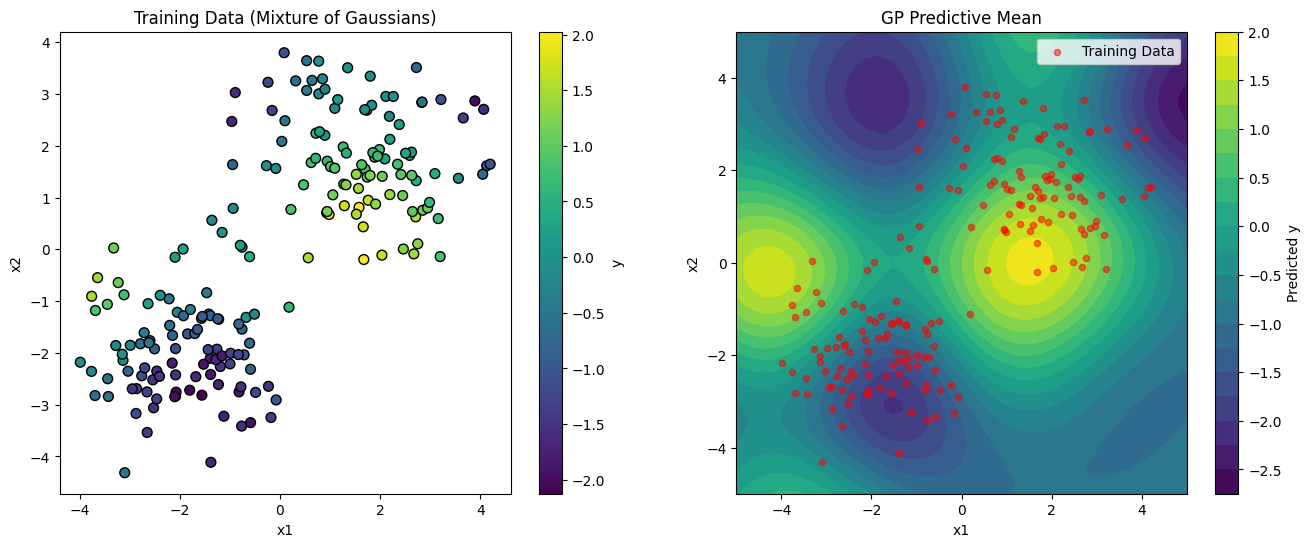

In [4]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data: Mixture of two Gaussians
def generate_mog_data(n=200):
    # Gaussian 1: Mean [2, 2], Covariance [[1, 0], [0, 1]]
    x1 = torch.randn(n//2, 2) + torch.tensor([2.0, 2.0])
    y1 = torch.sin(x1[:, 0]) + torch.cos(x1[:, 1]) + 0.2 * torch.randn(n//2)
    
    # Gaussian 2: Mean [-2, -2], Covariance [[1, 0], [0, 1]]
    x2 = torch.randn(n//2, 2) + torch.tensor([-2.0, -2.0])
    y2 = torch.sin(x2[:, 0]) + torch.cos(x2[:, 1]) + 0.2 * torch.randn(n//2)
    
    # Combine
    train_x = torch.cat([x1, x2], dim=0)
    train_y = torch.cat([y1, y2], dim=0)
    return train_x, train_y

train_x, train_y = generate_mog_data()

# Define GP model (2D input with RBF kernel)
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=2)  # ARD for 2D input
        )
        
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Initialize model and likelihood
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

# Training loop
def train_model(model, train_x, train_y, n_epochs=100):
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} - Loss: {loss.item():.3f}")

train_model(model, train_x, train_y, n_epochs=50)

# Generate test grid for prediction
test_res = 50
x1 = torch.linspace(-5, 5, test_res)
x2 = torch.linspace(-5, 5, test_res)
x1_grid, x2_grid = torch.meshgrid(x1, x2, indexing='ij')
test_x = torch.stack([x1_grid.flatten(), x2_grid.flatten()], dim=1)

# Inference
model.eval()
likelihood.eval()
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))
    predictive_mean = observed_pred.mean.reshape(test_res, test_res)
    predictive_std = observed_pred.stddev.reshape(test_res, test_res)

# Plot training data and predictions
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Training data (colored by target y)
sc = ax[0].scatter(train_x[:, 0], train_x[:, 1], c=train_y, cmap='viridis', s=50, edgecolors='k')
plt.colorbar(sc, ax=ax[0], label='y')
ax[0].set_title("Training Data (Mixture of Gaussians)")
ax[0].set_xlabel("x1")
ax[0].set_ylabel("x2")

# Predictive mean contour
contour = ax[1].contourf(x1_grid.numpy(), x2_grid.numpy(), predictive_mean.numpy(), cmap='viridis', levels=20)
plt.colorbar(contour, ax=ax[1], label='Predicted y')
ax[1].scatter(train_x[:, 0], train_x[:, 1], c='r', s=20, alpha=0.5, label='Training Data')
ax[1].set_title("GP Predictive Mean")
ax[1].set_xlabel("x1")
ax[1].set_ylabel("x2")
ax[1].legend()

plt.show()

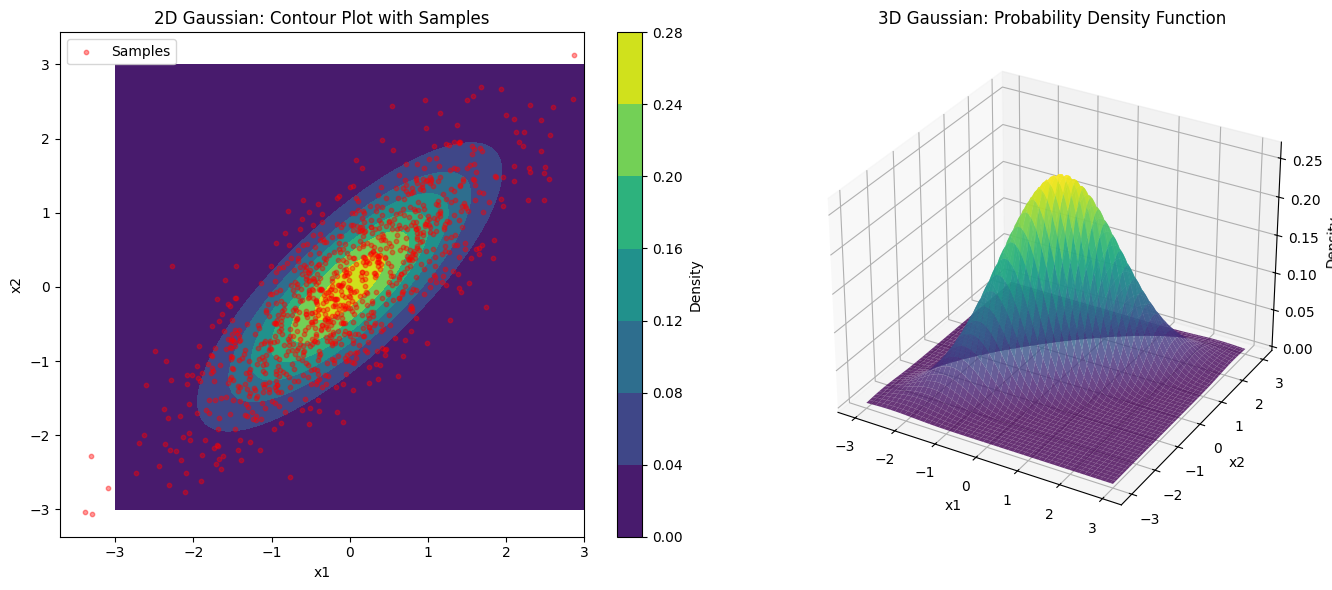

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D

# Define mean and covariance matrix for the 2D Gaussian
mean = np.array([0, 0])  # Mean vector [μ1, μ2]
cov = np.array([[1.0, 0.8],  # Covariance matrix
                [0.8, 1.0]])

# Generate grid points for visualization
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# Compute the multivariate Gaussian PDF
rv = multivariate_normal(mean, cov)
Z = rv.pdf(pos)

# Generate random samples from the distribution
samples = rv.rvs(size=1000)

# Plot the results
fig = plt.figure(figsize=(14, 6))

# Contour plot (2D)
ax1 = fig.add_subplot(121)
contour = ax1.contourf(X, Y, Z, cmap='viridis')
plt.colorbar(contour, ax=ax1, label='Density')
ax1.scatter(samples[:, 0], samples[:, 1], s=10, c='red', alpha=0.4, label='Samples')
ax1.set_title("2D Gaussian: Contour Plot with Samples")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.legend()

# 3D surface plot
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax2.set_title("3D Gaussian: Probability Density Function")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_zlabel("Density")

plt.tight_layout()
plt.show()

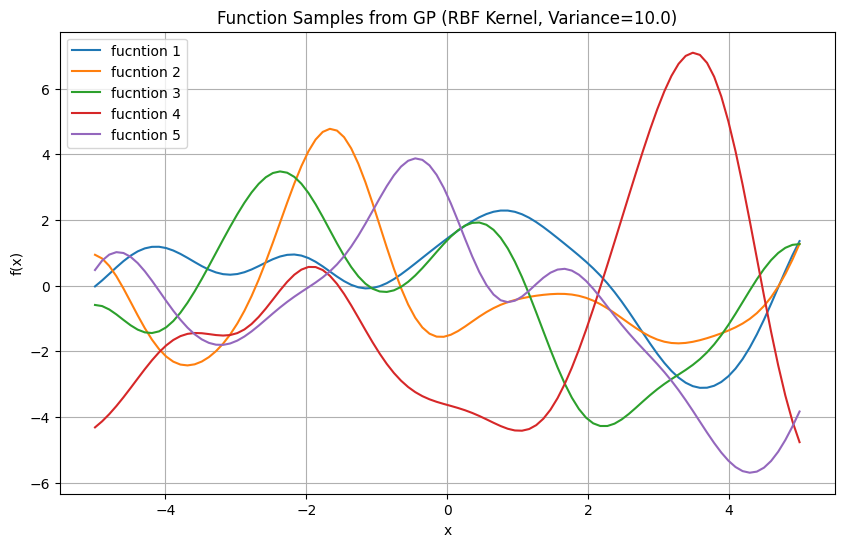

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Define the RBF kernel
def rbf_kernel(x1, x2, variance=1.0, lengthscale=1.0):
    """
    Radial Basis Function (RBF) kernel.
    Args:
        x1, x2: Input vectors.
        variance: Output variance (σ²).
        lengthscale: Length scale (l).
    Returns:
        Covariance matrix.
    """
    sqdist = np.sum(x1**2, axis=1).reshape(-1, 1) + np.sum(x2**2, axis=1) - 2 * np.dot(x1, x2.T)
    return variance * np.exp(-0.5 * sqdist / lengthscale**2)

# Parameters
variance = 10.0  # Variance of the RBF kernel
lengthscale = 1.0  # Length scale of the RBF kernel
num_samples = 5  # Number of function samples to generate
num_points = 100  # Number of points in the input grid

# Generate input grid
x = np.linspace(-5, 5, num_points).reshape(-1, 1)

# Compute the covariance matrix
K = rbf_kernel(x, x, variance=variance, lengthscale=lengthscale)

# Sample from the multivariate Gaussian distribution
samples = multivariate_normal.rvs(mean=np.zeros(num_points), cov=K, size=num_samples)

# Plot the samples
plt.figure(figsize=(10, 6))
for i in range(num_samples):
    plt.plot(x, samples[i], label=f'fucntion {i+1}')
plt.title(f'Function Samples from GP (RBF Kernel, Variance={variance})')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

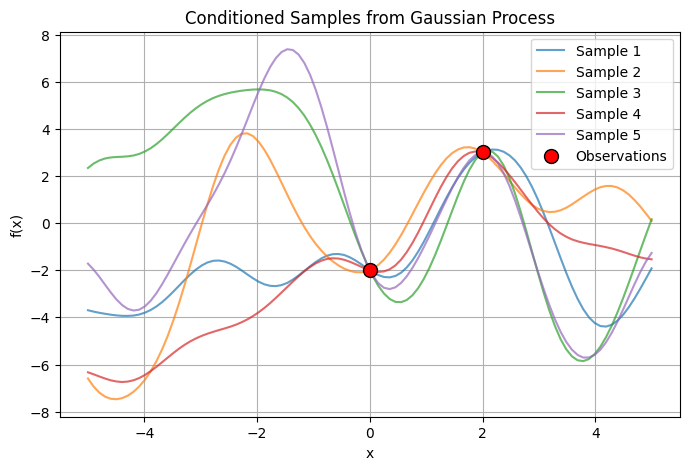

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Define the RBF Kernel function
def rbf_kernel(X1, X2, sigma2, length_scale):
    X1 = X1.reshape(-1, 1)  # Ensure column vector
    X2 = X2.reshape(-1, 1)  # Ensure column vector
    sqdist = (X1 - X2.T) ** 2  # Compute squared distance matrix
    return sigma2 * np.exp(-0.5 * sqdist / length_scale**2)

# GP hyperparameters
sigma2 = 10  # Variance
length_scale = 1.0  # Length scale for smoothness

# Test points
X = np.linspace(-5, 5, 100)

# Given training observations
X_train = np.array([0, 2])  # Training inputs
y_train = np.array([-2, 3])  # Training outputs

# Compute covariance matrices
K_nn = rbf_kernel(X_train, X_train, sigma2, length_scale) + 1e-6 * np.eye(len(X_train))
K_nX = rbf_kernel(X_train, X, sigma2, length_scale)
K_Xn = K_nX.T
K_XX = rbf_kernel(X, X, sigma2, length_scale) + 1e-6 * np.eye(len(X))

# Ensure y_train is a column vector
y_train = y_train.reshape(-1, 1)

# Compute posterior mean and covariance
K_nn_inv = np.linalg.inv(K_nn)
mu_posterior = (K_Xn @ K_nn_inv @ y_train).flatten()
Sigma_posterior = K_XX - K_Xn @ K_nn_inv @ K_nX

# Sample from the posterior distribution
num_samples = 5
samples_posterior = np.random.multivariate_normal(mu_posterior, Sigma_posterior, size=num_samples)

# Plot the conditioned samples
plt.figure(figsize=(8, 5))
for i in range(num_samples):
    plt.plot(X, samples_posterior[i], label=f"function {i+1}", alpha=0.7)

# Plot the observed training points
plt.scatter(X_train, y_train, color="red", zorder=3, label="Observations", edgecolors="black", s=100)

plt.title("Conditioned Samples from Gaussian Process")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()


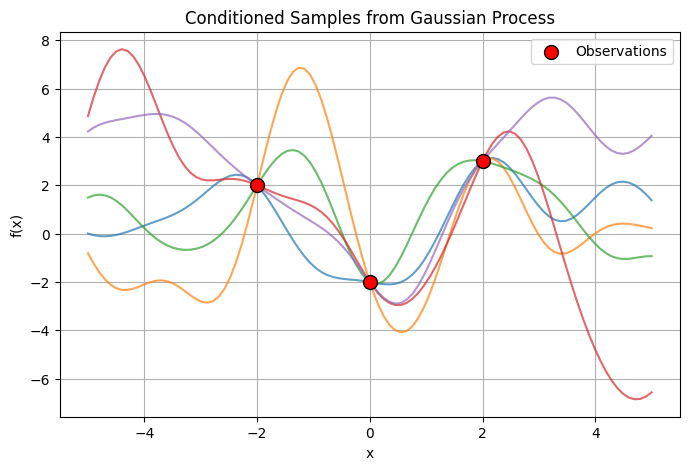

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Define the RBF Kernel function
def rbf_kernel(X1, X2, sigma2, length_scale):
    X1 = X1.reshape(-1, 1)  # Ensure column vector
    X2 = X2.reshape(-1, 1)  # Ensure column vector
    sqdist = (X1 - X2.T) ** 2  # Compute squared distance matrix
    return sigma2 * np.exp(-0.5 * sqdist / length_scale**2)

# GP hyperparameters
sigma2 = 10  # Variance
length_scale = 1.0  # Length scale for smoothness

# Test points
X = np.linspace(-5, 5, 100)

# Given training observations
X_train = np.array([-2, 0, 2])  # Training inputs
y_train = np.array([2, -2, 3])  # Training outputs

# Compute covariance matrices
K_nn = rbf_kernel(X_train, X_train, sigma2, length_scale) + 1e-6 * np.eye(len(X_train))
K_nX = rbf_kernel(X_train, X, sigma2, length_scale)
K_Xn = K_nX.T
K_XX = rbf_kernel(X, X, sigma2, length_scale) + 1e-6 * np.eye(len(X))

# Ensure y_train is a column vector
y_train = y_train.reshape(-1, 1)

# Compute posterior mean and covariance
K_nn_inv = np.linalg.inv(K_nn)
mu_posterior = (K_Xn @ K_nn_inv @ y_train).flatten()
Sigma_posterior = K_XX - K_Xn @ K_nn_inv @ K_nX

# Sample from the posterior distribution
num_samples = 5
samples_posterior = np.random.multivariate_normal(mu_posterior, Sigma_posterior, size=num_samples)

# Plot the conditioned samples
plt.figure(figsize=(8, 5))
for i in range(num_samples):
    #plt.plot(X, samples_posterior[i], label=f"Sample {i+1}", alpha=0.7)
    plt.plot(X, samples_posterior[i], alpha=0.7)

# Plot the observed training points
plt.scatter(X_train, y_train, color="red", zorder=3, label="Observations", edgecolors="black", s=100)

plt.title("Conditioned Samples from Gaussian Process")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()


In [30]:
#**making predictions

# Define new test points for prediction
X_star = np.array([-3, 0.2, 1, 3, 4])

# Compute new covariance matrices
K_nstar = rbf_kernel(X_train, X_star, sigma2, length_scale)  # (2,4)
K_starn = K_nstar.T  # (4,2)
K_starstar = rbf_kernel(X_star, X_star, sigma2, length_scale) + 1e-6 * np.eye(len(X_star))  # (4,4)

# Compute posterior mean and covariance for test points
mu_star = (K_starn @ K_nn_inv @ y_train).flatten()  # Mean prediction at X_star
Sigma_star = K_starstar - K_starn @ K_nn_inv @ K_nstar  # Covariance at X_star

# Extract standard deviations (uncertainty)
std_dev_star = np.sqrt(np.diag(Sigma_star))

# Print predictions with uncertainties
for i, x in enumerate(X_star):
    print(f"Prediction at x={x:.1f}: Mean={mu_star[i]:.3f}, StdDev={std_dev_star[i]:.3f}")


Prediction at x=-3.0: Mean=1.410, StdDev=2.504
Prediction at x=0.2: Mean=-1.844, StdDev=0.575
Prediction at x=1.0: Mean=0.388, StdDev=1.866
Prediction at x=3.0: Mean=2.016, StdDev=2.504
Prediction at x=4.0: Mean=0.456, StdDev=3.133


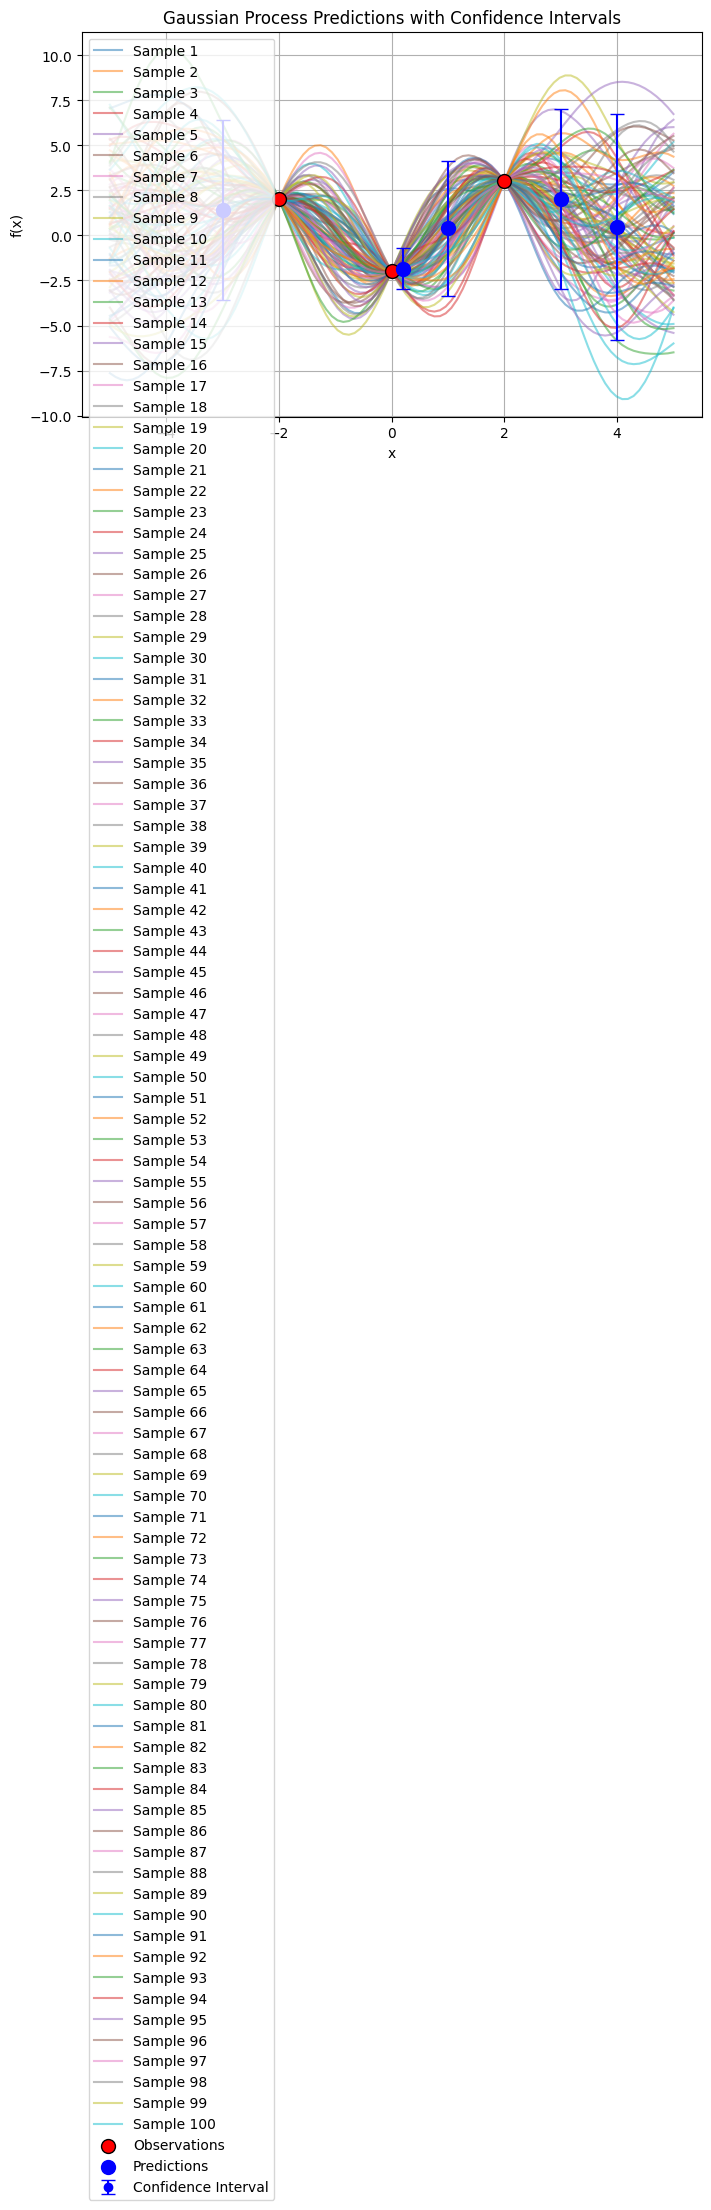

In [31]:
# Plot the original GP samples
plt.figure(figsize=(8, 5))
for i in range(num_samples):
    plt.plot(X, samples_posterior[i], label=f"Sample {i+1}", alpha=0.5)

# Plot the observed training points
plt.scatter(X_train, y_train, color="red", zorder=3, label="Observations", edgecolors="black", s=100)

# Plot the mean predictions at test points
plt.scatter(X_star, mu_star, color="blue", marker='o', label="Predictions", zorder=3, s=100)

# Add confidence intervals (±2 standard deviations)
plt.errorbar(X_star, mu_star, yerr=2 * std_dev_star, fmt='o', color='blue', capsize=5, label="Confidence Interval")

# Final plot formatting
plt.title("Gaussian Process Predictions with Confidence Intervals")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()
